# Preliminaries

* Our function is x[n] = 0.5 * np.cos(2*np.pi*1000*n/fs) for n= 0,..,1023 total 1024.
* 8-bit information is given meaning that 2ˆ8 = 256 distinct levels are defined for the array of focus
* Array of focus is [-1,1] meaning that 1 - (-1)/2ˆ8 = 2/256 is our step size.
* Then we will use midrise function for mapping to nearest minimum.
* our x[n] amplitude 0.5 fits in between [-1,1] otherwise, clipping would happen and catastrophic errors would be occuring.

In [151]:
import numpy as np
import matplotlib.pyplot as plt

# Given Parameters
fs = 8000
N = 1024
n = np.arange(N)
f_zero = 1000
x = 0.5 * np.cos(2*np.pi*f_zero*n/fs)  # input values fixed
bits = 8
levels = 2**bits
step_size = (1 - (-1))/(levels) # the range

# Quantizer Implementation (Part A)

## Q[*] Mid-Rise Function

Explanations given in comments of the code.

In [155]:
#mid-rise quantizer Q(x) on [-1,1]
def midrise_quantize(x):

    # If non-negative input, quantize on positive-side.
    if x >= 0:
        # how many steps above zero
        i = np.floor(x / step_size)

        # Check maximum available, then confine value to that if its bigger, thats why above 1 or below -1 amp has error.
        i = min(i, (levels/2) - 1)

        # since we are in between [0 , 1] for x >= 0 mid is 0.5 so i + 0.5 with step-size now will give us our quantized value.
        return (i + 0.5) * step_size

    else:
        # All same as if but with -1* if
        i = np.floor(-x / step_size)

        i = min(i, (levels/2) - 1)

        return -(i + 0.5) * step_size


## Quantizer A

* Quantizer A is defined uniformly.
* Formulation as;

* y_A[n] = Q(x[n])
* e_A[n] = x[n] - y_A[n]

In [156]:
# Quantizer A (uniform)
y_A = np.array([midrise_quantize(step) for step in x])
e_A = x - y_A

## Quantizer B

* Quantizer B as defined as a system is a first-order feedback quantizer that each input is fed to error with output substracted, then with previous error is substracted from current input we apply mid-rise quantizer to this and then the output is taken. Later from this output as mentioned in the beginning another error is foundt then the prior error is updated with Zˆ-1. first error is set to e[−1]=0 and for n >= 0.

* v[n] = x[n] - e[n-1]
* y_B[n] = Q(v[n])  (same Q as quantizer A)
* e[n]  = x[n] - y_B[n]   (the quantization error fed to the prior error.)
* e[n-1] = e[n]

In [157]:
# Quantizer B (error-feedback) First-order
e_prev = 0.0           # this holds e[n-1]
y_B = np.zeros(N)

for n in range(N):
    v = x[n] - e_prev      # subtract delayed error: x[n] - e[n-1]
    y_B[n] = midrise_quantize(v)
    e_now   = x[n] - y_B[n] # compute current error e[n]
    e_prev  = e_now        # <-- this assignment implements Z^{-1}


e_B = x - y_B

# Spectral Analysis (Part B)

In [158]:
E_A = np.fft.fft(e_A) # np fast fourier transform
E_B = np.fft.fft(e_B) # np fast fourier transform
freq = np.fft.fftfreq(N, 1/fs) # for our sampling frequency here gives sampling period for our 1024 point, formatted for fft in np.


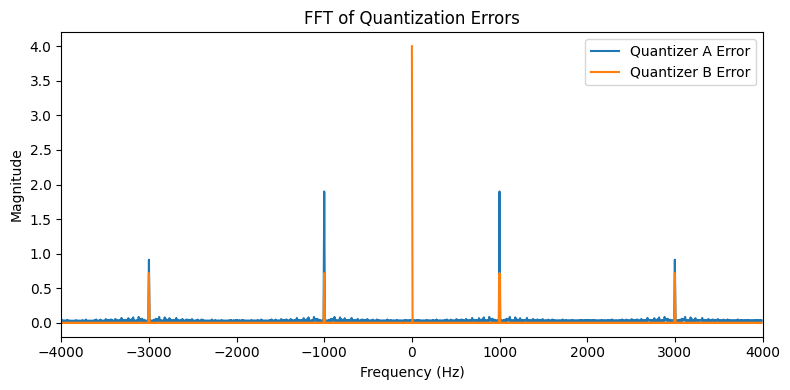

In [159]:
plt.figure(figsize=(8,4))
plt.plot(freq, np.abs(E_A), label='Quantizer A Error')
plt.plot(freq, np.abs(E_B), label='Quantizer B Error')
plt.xlim(-fs/2, fs/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of Quantization Errors')
plt.legend()
plt.tight_layout()
plt.show()

In [160]:
# Now only non-negative frequencies for plotting
pos = freq >= 0 # positive frequency indices taken.
freq_plot = freq[pos] # values from 0 and positives.
magA = np.abs(E_A)[pos] # here we only get positive frequencies
magB = np.abs(E_B)[pos]

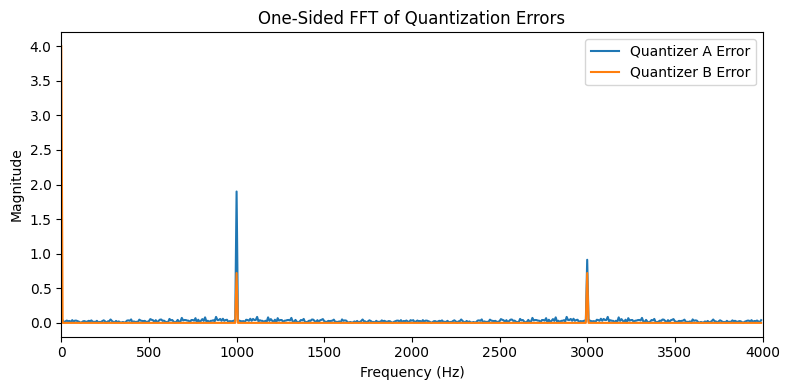

In [161]:
plt.figure(figsize=(8,4))
plt.plot(freq_plot, magA, label='Quantizer A Error')
plt.plot(freq_plot, magB, label='Quantizer B Error')
plt.xlim(0, fs/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('One‐Sided FFT of Quantization Errors') # only positive values are put, that's why one-sided
plt.legend()
plt.tight_layout()
plt.show()

When we have computed and plotted 1024-points FFT of quantization errors of signals. We see that;
For;

Quantizer A which is uniform quantization:
* Peak at  f_0 = 1kHz, fundamental frequency given in input as 1000*n/fs the 1000 here.
* and white noise everywhere except 3kHz because
* quantization error is now a periodic sequence that matches with our input with f = k*f_s/L where L = f_s/f_0 up to nyquist.

Quantizer B (feedback):
* much smaller error at fundamental frequency, higher errors at its harmonic distortions, from the static nonlinearity provided by the mid-rise.
* first-order feedback loops for noise-shaping with transfer function of H(z) = 1 − (zˆ{−1})
* delivers noise to the higher frequencies, and removes artifacts from desired frequency.

# Signal-to-Noise Ratio (SNR) - Part C

In [162]:
snr_A = 10*np.log10(np.sum(x**2) / np.sum(e_A**2))
snr_B = 10*np.log10(np.sum(x**2) / np.sum(e_B**2))
print(f"Quantizer A - Signal To Noise Ratio = {snr_A:.2f} dB \nQuantizer B - Signal To Noise Ratio = {snr_B:.2f} dB")


Quantizer A - Signal To Noise Ratio = 41.21 dB 
Quantizer B - Signal To Noise Ratio = 38.60 dB


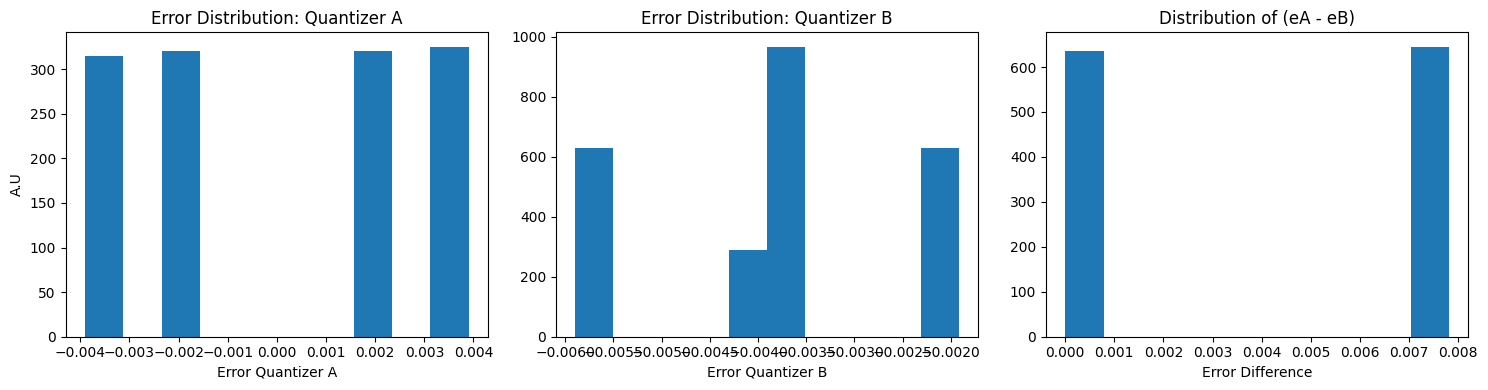

In [163]:
err_diff = e_A - e_B

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(e_A, bins=10, density=True)
axes[0].set_title('Error Distribution: Quantizer A')
axes[0].set_xlabel('Error Quantizer A')
axes[0].set_ylabel('A.U') # Arbitrary unit just for visualization

axes[1].hist(e_B, bins=10, density=True)
axes[1].set_title('Error Distribution: Quantizer B')
axes[1].set_xlabel('Error Quantizer B')

axes[2].hist(err_diff, bins=10, density=True)
axes[2].set_title('Distribution of (eA - eB)')
axes[2].set_xlabel('Error Difference')

plt.tight_layout()
plt.show()

* Even though the Signal-to-Noise ratio of second(B) quantizer-B is seem worse, the noise is on the tails rather than the desired frequency, hence it can be filtered out and the desired output can be enhanced via a digital low-pass filter. Also the error values are generally smaller than the error at quantizer A.

* This means that quantizer-B has worse quality on other frequencies to compensate the quality increase in fundamental frequency, desired frequency.

# Comments (Bonus)

| Topics of Difference              | Quantizer A                          | Quantizer B                                  |
|---------------------|---------------------------------------------------------|---------------------------------------------------------------|
| **Operation**       | Quantizes `x[n]` to the nearest bin, rounds to the nearest level.       | Quantizes after substracting previous error `e[n-1]` from input `x[n]`. |
| **Time-Domain Error** | Independent errors and uniform over step-size. | Correlated errors, near zero at desired spots, larger outside. |
| **Error Distribution** | Mostly flat, doesnt focus on any point, gives error at harmonic distortions.              | Heavy-tailed and good at desired valuePeaked at zero with heavy tails.                              |
| **Frequency-Domain** | White noise with peak at fundamental frequency \(f_0\). | Better at fundamental frequency \(f_0\), worse performance on harmonics. |
| **Total SNR**       | Better than B (~41.21 dB).           | Lower overall, (~38.6 dB), but better on desired region. |


* Even if Quantizer B has lower SNR value, due to its noise-shaping characteristic, it can be used valuably if out-of-band noise can be tolerated or removed and what is important is in-band fidelity.

In Audio Devices
* Oversampling of input signal, as in high-def audio for audiophiles, then shape the noise out of audible band, apply the digital filter to recover this band, and now we have high-res audio.

In Visual Systems
* Error is spread to other pixels, hence general quality is preserved for desired region with a little lower quality, but balanced.

In communication
* Channel quality can be increased by pushing out the noise out of the channel in case.

In Instrumentation
* Where a strict band of signal is accepted rest is rejected.